# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:
import os
# TF-MOT (pruning) relies on the Keras 2 API. On TensorFlow 2.16+ tf.keras
# defaults to Keras 3, so we opt in to the legacy Keras backend BEFORE
# importing TensorFlow. This keeps the notebook working on newer TF builds.
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")

import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /Users/lukevalerio/Documents/TinyML/Lab3/UCI HAR Dataset


## 3. Load the Data


In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # Load features as float32 and labels as zero-based int32 class indices.
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt").astype(np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt").astype(np.int32) - 1
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt").astype(np.float32)
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt").astype(np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:
def build_teacher_model(input_dim, num_classes):
    # Larger, more expressive teacher DNN for the 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # Smaller student DNN -- the model we ultimately want to deploy.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 512)               287744    


 dense_1 (Dense)             (None, 256)               131328    


...

 dense_3 (Dense)             (None, 6)                 774       


Total params: 452742 (1.73 MB)


Trainable params: 452742 (1.73 MB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## 6. Train the Teacher Model


In [6]:
teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1
)

Epoch 1/20


 1/92 [..............................] - ETA: 54s - loss: 1.9886 - accuracy: 0.1406

17/92 [====>.........................] - ETA: 0s - loss: 0.9786 - accuracy: 0.5809 

33/92 [=========>....................] - ETA: 0s - loss: 0.7485 - accuracy: 0.6728

50/92 [===============>..............] - ETA: 0s - loss: 0.6064 - accuracy: 0.7341

...

43/92 [=============>................] - ETA: 0s - loss: 0.0734 - accuracy: 0.9742

56/92 [=================>............] - ETA: 0s - loss: 0.0729 - accuracy: 0.9729

69/92 [=====================>........] - ETA: 0s - loss: 0.0717 - accuracy: 0.9726

82/92 [=========================>....] - ETA: 0s - loss: 0.0852 - accuracy: 0.9667

92/92 [==============================] - 0s 4ms/step - loss: 0.0909 - accuracy: 0.9640 - val_loss: 0.1720 - val_accuracy: 0.9218


### Teacher Training Curves


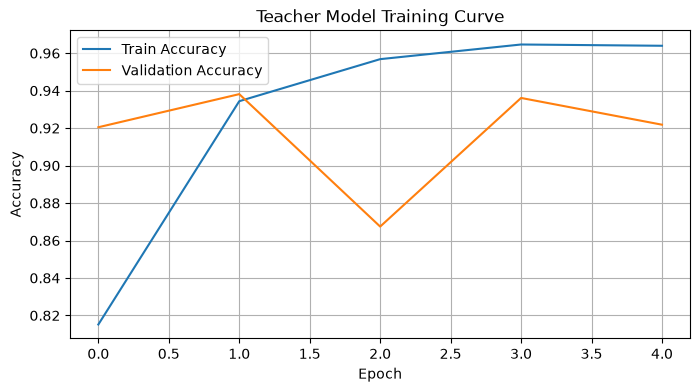

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


Teacher Test Accuracy: 0.9410

                    precision    recall  f1-score   support

           WALKING     0.9814    0.9597    0.9704       496
  WALKING_UPSTAIRS     0.9411    0.9490    0.9450       471
WALKING_DOWNSTAIRS     0.9184    0.9381    0.9282       420
           SITTING     0.8525    0.9532    0.9000       491
          STANDING     0.9575    0.8477    0.8993       532
            LAYING     0.9981    1.0000    0.9991       537

          accuracy                         0.9410      2947
         macro avg     0.9415    0.9413    0.9403      2947
      weighted avg     0.9432    0.9410    0.9410      2947



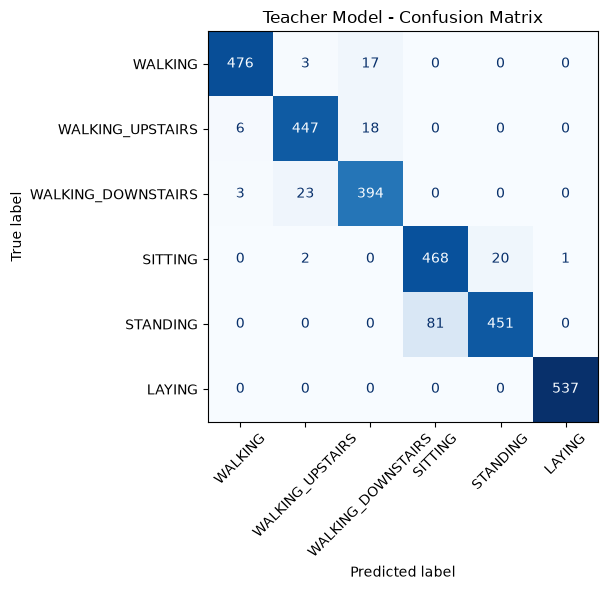

In [8]:
# Evaluate the trained teacher model on the test set.
# (Note: the baseline student is trained in Section 8 below; this cell
# provides the teacher evaluation required for the Part I comparison.)
teacher_probs = teacher_model.predict(X_test, verbose=0)
teacher_preds = np.argmax(teacher_probs, axis=1)
teacher_acc = accuracy_score(y_test, teacher_preds)

print(f"Teacher Test Accuracy: {teacher_acc:.4f}\n")
print(classification_report(y_test, teacher_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, teacher_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Teacher Model - Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [9]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20


 1/92 [..............................] - ETA: 37s - loss: 2.2078 - accuracy: 0.2031

61/92 [==================>...........] - ETA: 0s - loss: 0.8528 - accuracy: 0.7141 

92/92 [==============================] - 1s 2ms/step - loss: 0.6947 - accuracy: 0.7674 - val_loss: 0.3262 - val_accuracy: 0.8906


Epoch 2/20


...

92/92 [==============================] - 0s 1ms/step - loss: 0.0826 - accuracy: 0.9685 - val_loss: 0.1519 - val_accuracy: 0.9415


Epoch 10/20


 1/92 [..............................] - ETA: 0s - loss: 0.0649 - accuracy: 0.9688

61/92 [==================>...........] - ETA: 0s - loss: 0.0609 - accuracy: 0.9775

92/92 [==============================] - 0s 1ms/step - loss: 0.0623 - accuracy: 0.9764 - val_loss: 0.1874 - val_accuracy: 0.9341


## 9. Evaluate the Baseline Student Model


In [10]:
# Evaluate the baseline (hard-label) student on the test set.
student_baseline_probs = student_baseline_model.predict(X_test, verbose=0)
student_baseline_preds = np.argmax(student_baseline_probs, axis=1)
student_baseline_acc = accuracy_score(y_test, student_baseline_preds)

print(f"Baseline Student Test Accuracy: {student_baseline_acc:.4f}\n")
print(classification_report(y_test, student_baseline_preds, target_names=class_names, digits=4))

Baseline Student Test Accuracy: 0.9250

                    precision    recall  f1-score   support

           WALKING     0.9040    0.9677    0.9348       496
  WALKING_UPSTAIRS     0.9061    0.9214    0.9137       471
WALKING_DOWNSTAIRS     0.9526    0.8619    0.9050       420
           SITTING     0.9168    0.8982    0.9074       491
          STANDING     0.8801    0.9248    0.9019       532
            LAYING     1.0000    0.9628    0.9810       537

          accuracy                         0.9250      2947
         macro avg     0.9266    0.9228    0.9240      2947
      weighted avg     0.9266    0.9250    0.9251      2947



In [11]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # 1. Teacher predictions (frozen; no training)
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            # 2. Student predictions inside the tape
            student_predictions = self.student(x, training=True)

            # 3. Hard-label loss against the true classes
            student_loss = self.student_loss_fn(y, student_predictions)

            # 4. Soft-label loss between temperature-softened teacher and
            #    student distributions (scaled by T^2 to keep gradient
            #    magnitudes comparable across temperatures)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            ) * (self.temperature ** 2)

            # 5. Weighted combination of the two losses
            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [12]:
distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)

Epoch 1/20


 1/92 [..............................] - ETA: 49s - accuracy: 0.2812 - student_loss: 1.9001 - distillation_loss: 0.0674

33/92 [=========>....................] - ETA: 0s - accuracy: 0.5601 - student_loss: 1.1808 - distillation_loss: 0.0498 

67/92 [====================>.........] - ETA: 0s - accuracy: 0.6882 - student_loss: 0.8951 - distillation_loss: 0.0371

92/92 [==============================] - 1s 3ms/step - accuracy: 0.7286 - student_loss: 0.7640 - distillation_loss: 0.0310 - val_accuracy: 0.9075 - val_student_loss: 0.1748


...

 1/92 [..............................] - ETA: 0s - accuracy: 0.9688 - student_loss: 0.0765 - distillation_loss: 0.0056

29/92 [========>.....................] - ETA: 0s - accuracy: 0.9790 - student_loss: 0.0634 - distillation_loss: 0.0020

58/92 [=================>............] - ETA: 0s - accuracy: 0.9782 - student_loss: 0.0643 - distillation_loss: 0.0019

86/92 [===========================>..] - ETA: 0s - accuracy: 0.9780 - student_loss: 0.0638 - distillation_loss: 0.0019

92/92 [==============================] - 0s 2ms/step - accuracy: 0.9777 - student_loss: 0.0654 - distillation_loss: 0.0019 - val_accuracy: 0.9279 - val_student_loss: 0.0019


## 11. Train the Distilled Student


In [13]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20


 1/92 [..............................] - ETA: 48s - accuracy: 0.0938 - student_loss: 1.9819 - distillation_loss: 0.0733

35/92 [==========>...................] - ETA: 0s - accuracy: 0.5304 - student_loss: 1.1472 - distillation_loss: 0.0487 

71/92 [======================>.......] - ETA: 0s - accuracy: 0.6754 - student_loss: 0.8509 - distillation_loss: 0.0347

92/92 [==============================] - 1s 3ms/step - accuracy: 0.7198 - student_loss: 0.7397 - distillation_loss: 0.0294 - val_accuracy: 0.8926 - val_student_loss: 0.0918


...

 1/92 [..............................] - ETA: 0s - accuracy: 1.0000 - student_loss: 0.0189 - distillation_loss: 0.0029

31/92 [=========>....................] - ETA: 0s - accuracy: 0.9728 - student_loss: 0.0597 - distillation_loss: 0.0031

58/92 [=================>............] - ETA: 0s - accuracy: 0.9776 - student_loss: 0.0523 - distillation_loss: 0.0030

86/92 [===========================>..] - ETA: 0s - accuracy: 0.9809 - student_loss: 0.0461 - distillation_loss: 0.0028

92/92 [==============================] - 0s 2ms/step - accuracy: 0.9804 - student_loss: 0.0484 - distillation_loss: 0.0028 - val_accuracy: 0.9456 - val_student_loss: 0.0015


### Distillation Training Curves


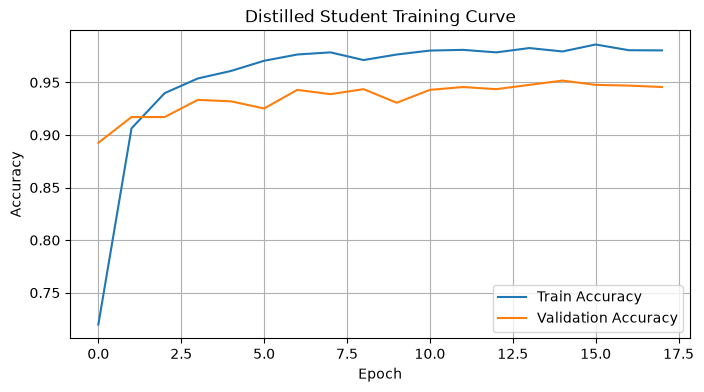

In [14]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9342

                    precision    recall  f1-score   support

           WALKING     0.9301    0.9657    0.9476       496
  WALKING_UPSTAIRS     0.9448    0.9087    0.9264       471
WALKING_DOWNSTAIRS     0.9384    0.9429    0.9406       420
           SITTING     0.9503    0.8574    0.9015       491
          STANDING     0.8571    0.9586    0.9051       532
            LAYING     1.0000    0.9665    0.9830       537

          accuracy                         0.9342      2947
         macro avg     0.9368    0.9333    0.9340      2947
      weighted avg     0.9366    0.9342    0.9343      2947



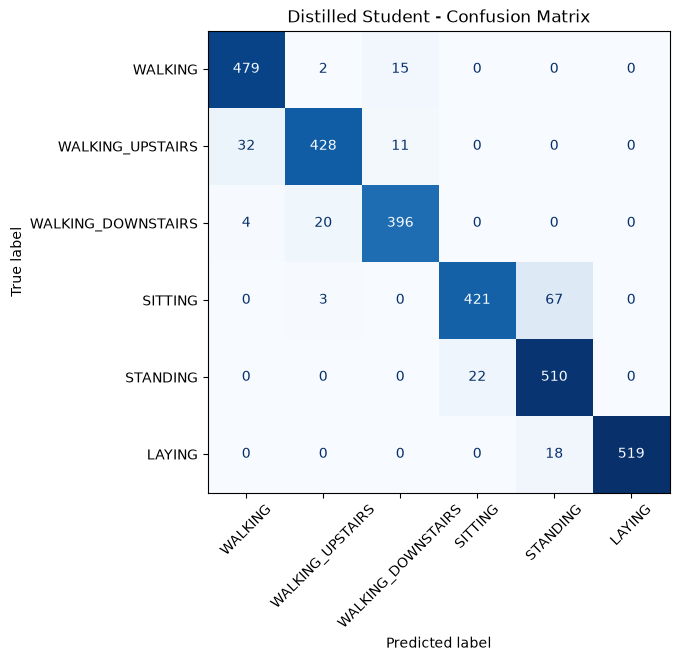

In [15]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [16]:
# Part I comparison: teacher vs baseline student vs distilled student (Keras models).
part1_results = pd.DataFrame([
    ["Teacher", teacher_model.count_params(), teacher_acc],
    ["Baseline Student (hard labels)", student_baseline_model.count_params(), student_baseline_acc],
    ["Distilled Student", distilled_student.count_params(), distilled_acc],
], columns=["Model", "Parameters", "Test Accuracy"])

part1_results

,Model,Parameters,Test Accuracy
0,Teacher,452742,0.940957
1,Baseline Student (hard labels),38246,0.925008
2,Distilled Student,38246,0.934170


In [17]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # Yield small calibration batches from X_train.
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]

# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [18]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [19]:
# Convert the distilled student to FP32 TensorFlow Lite.
# (Defines distilled_fp32_acc / distilled_fp32_size_kb used in the Part II comparison.)
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_student_fp32.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)

print(f"Distilled Student FP32 TFLite Accuracy: {distilled_fp32_acc:.4f}")
print(f"Distilled Student FP32 TFLite Size (KB): {distilled_fp32_size_kb:.2f}")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9l849387/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9l849387/assets


Distilled Student FP32 TFLite Accuracy: 0.9342
Distilled Student FP32 TFLite Size (KB): 151.53


W0000 00:00:1784245121.886374 54520892 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784245121.886394 54520892 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784245121.886709 54520892 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9l849387
I0000 00:00:1784245121.887286 54520892 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784245121.887291 54520892 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9l849387
I0000 00:00:1784245121.890306 54520892 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1784245121.890832 54520892 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784245121.908732 54520892 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp9l849387
I0000 00:00:1784245121.915864 54

In [20]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# 1. Clone the distilled student model.
student_for_pruning = keras.models.clone_model(distilled_student)
# 2. Copy the distilled student weights into the cloned model.
student_for_pruning.set_weights(distilled_student.get_weights())

# 3. Wrap the cloned model with pruning wrappers.
pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10


 1/92 [..............................] - ETA: 2:07 - loss: 0.0654 - accuracy: 0.9688

53/92 [================>.............] - ETA: 0s - loss: 0.0369 - accuracy: 0.9876  

92/92 [==============================] - 2s 4ms/step - loss: 0.0380 - accuracy: 0.9883 - val_loss: 0.1302 - val_accuracy: 0.9470


Epoch 2/10


...

92/92 [==============================] - 0s 1ms/step - loss: 0.4704 - accuracy: 0.8680 - val_loss: 0.1959 - val_accuracy: 0.9470


Epoch 6/10


 1/92 [..............................] - ETA: 0s - loss: 0.1470 - accuracy: 1.0000

49/92 [==============>...............] - ETA: 0s - loss: 0.4004 - accuracy: 0.9078

92/92 [==============================] - 0s 1ms/step - loss: 0.6579 - accuracy: 0.8385 - val_loss: 0.7179 - val_accuracy: 0.7947


## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [21]:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmptorg3jvc/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmptorg3jvc/assets


W0000 00:00:1784245127.837443 54520892 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784245127.837458 54520892 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


I0000 00:00:1784245127.837613 54520892 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmptorg3jvc
I0000 00:00:1784245127.839958 54520892 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784245127.839964 54520892 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmptorg3jvc
I0000 00:00:1784245127.853412 54520892 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784245127.901857 54520892 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmptorg3jvc
I0000 00:00:1784245127.919093 54520892 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 81483 microseconds.
/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please 

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmplp4rtqra/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmplp4rtqra/assets


W0000 00:00:1784245128.616203 54520892 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784245128.616216 54520892 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Pruned distilled model with mask accuracy: 0.9287
Pruned distilled model with mask size (KB): 304.35
Stripped sparse distilled model accuracy: 0.9287
Stripped sparse distilled model size (KB): 105.90


I0000 00:00:1784245128.616363 54520892 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmplp4rtqra
I0000 00:00:1784245128.616902 54520892 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784245128.616907 54520892 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmplp4rtqra
I0000 00:00:1784245128.620115 54520892 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784245128.635558 54520892 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmplp4rtqra
I0000 00:00:1784245128.641457 54520892 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 25096 microseconds.
W0000 00:00:1784245128.696293 54520892 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/te

## 17. Convert the Pruned Distilled Student Before and After Stripping


In [22]:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpcbo6tksi/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpcbo6tksi/assets


Stripped Sparse + INT8 Accuracy: 0.9270
Stripped Sparse + INT8 Size (KB): 58.32


/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1784245129.880460 54520892 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784245129.880478 54520892 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784245129.880824 54520892 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpcbo6tksi
I0000 00:00:1784245129.881569 54520892 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784245129.881579 54520892 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpcbo6tksi
I0000 00:00:1784245129.885805 54520892 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784245129.908513 54520892 loader.cc:220] Running initialization op on SavedModel bundle at pat

## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [23]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmps1_rsobr/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmps1_rsobr/assets


Stripped Sparse + INT8 Accuracy: 0.9270
Stripped Sparse + INT8 Size (KB): 58.32


/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1784245130.708340 54520892 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784245130.708352 54520892 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784245130.708513 54520892 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmps1_rsobr
I0000 00:00:1784245130.709131 54520892 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784245130.709136 54520892 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmps1_rsobr
I0000 00:00:1784245130.712484 54520892 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784245130.727252 54520892 loader.cc:220] Running initialization op on SavedModel bundle at pat

## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [24]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.934170,151.531250
1,Pruned Distilled TFLite (with mask),FP32,0.928741,304.347656
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.928741,105.902344
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.927044,58.320312


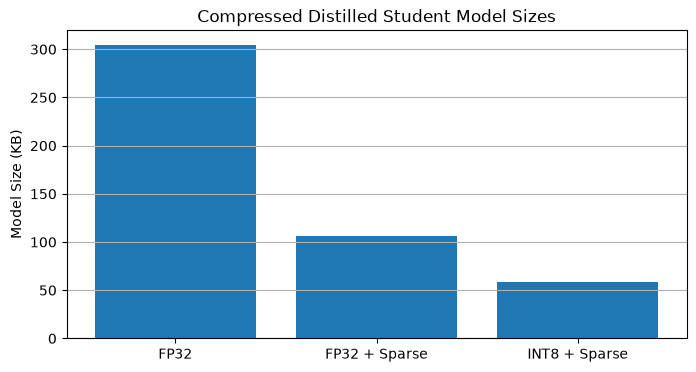

In [25]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


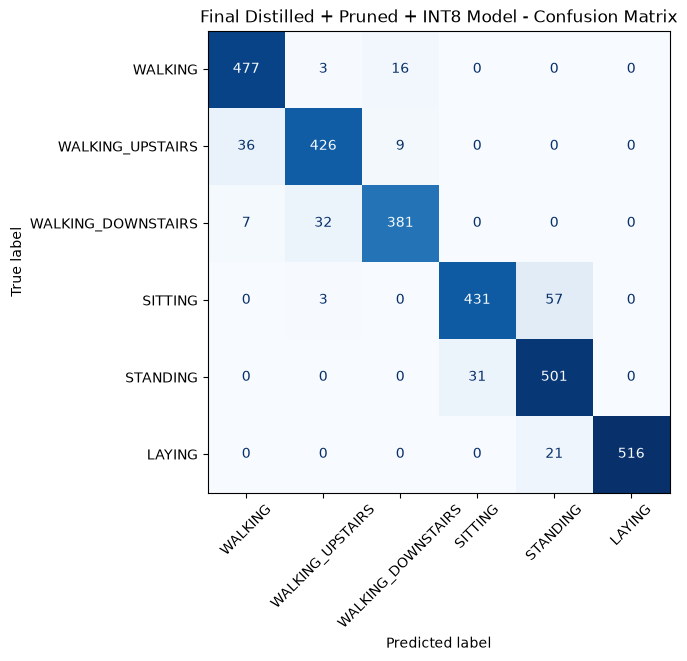

In [26]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:

**1. How did the baseline student compare with the distilled student?**

Both share the identical 38,246-parameter architecture, but the **baseline student (hard labels only) reached 0.9250** while the **distilled student reached 0.9342** -- a **+0.92 percentage-point gain** purely from changing the training signal. The distilled student closed most of the gap to the 452,742-parameter teacher (0.9410) while being ~12x smaller.

**2. Did knowledge distillation help the smaller model retain performance?**

**Yes, clearly.** The teacher's temperature-softened output distribution (T=4.0) encodes inter-class similarity structure -- e.g., how confusable SITTING and STANDING are for a given sample -- that one-hot labels discard. Training the student against a blend of hard labels (alpha=0.3) and this soft signal (0.7 weight, KL divergence) recovered 58% of the teacher-student accuracy gap (0.9250 -> 0.9342 vs teacher 0.9410) at zero inference cost: the deployed model is unchanged in size and speed.

**3. What happened to the model size after pruning and after INT8 quantization?**

Starting from the distilled student's 151.5 KB FP32 TFLite: exporting with pruning wrappers attached **doubled** it to 304.3 KB (masks stored alongside weights). After `strip_pruning` + sparsity-aware conversion it dropped to **105.9 KB**, and full INT8 quantization on top brought it to **58.3 KB** -- a 2.6x reduction from the distilled FP32 model, and ~12.5x smaller than the FP32 baseline DNN of the earlier notebooks (726.7 KB). Accuracy costs were small: 0.9342 -> 0.9287 from pruning (-0.55 pp), -> 0.9270 from INT8 (-0.17 pp).

**4. Which model would you choose for Arduino deployment, and why?**

The **final stripped sparse INT8 model (58.3 KB, 0.9270)**. An Arduino-class MCU (e.g., Nano 33 BLE Sense: 256 KB RAM / 1 MB flash) needs a small flash image, a small tensor arena, and integer-only compute -- this model satisfies all three, leaves ample headroom for application code, and gives up only 1.4 pp versus the huge teacher. Every other variant is either float-typed or 2-5x larger for at most +0.7 pp accuracy.

**5. Why is the final sparse INT8 model a good TinyML deployment candidate?**

It stacks three complementary compressions, each attacking a different redundancy: **distillation** shrinks the architecture (452k -> 38k params) while transferring the teacher's knowledge; **pruning** removes 85% of the remaining weights that contribute little; **INT8 quantization** cuts each surviving weight from 32 to 8 bits and makes all arithmetic integer -- faster and far more energy-efficient on MCU/DSP hardware, with no floating-point unit required. The compounded result is a 58 KB, all-integer model retaining 92.7% accuracy -- comfortably within TinyML memory, latency, and power budgets.

## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
